In [4]:
import torch
import torch.nn as nn
import numpy as np


In [5]:
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
X = np.load("../data/processed/X.npy")
y = np.load("../data/processed/y.npy")

X_torch = torch.tensor(X, dtype=torch.float32)

input_dim = X.shape[1]          # 402
num_classes = len(np.unique(y)) # 4

model = EmotionClassifier(input_dim, num_classes)
model.load_state_dict(torch.load("../models/emotion_classifier.pt", map_location="cpu"))
model.eval()


EmotionClassifier(
  (net): Sequential(
    (0): Linear(in_features=402, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

with torch.no_grad():
    logits = model(X_torch)
    y_pred = torch.argmax(logits, dim=1).numpy()


In [10]:
cm = confusion_matrix(y, y_pred)
print(cm)


[[ 910   56   10   24]
 [  80 2739   70  111]
 [  16   75  831   78]
 [  27   68   61 2844]]


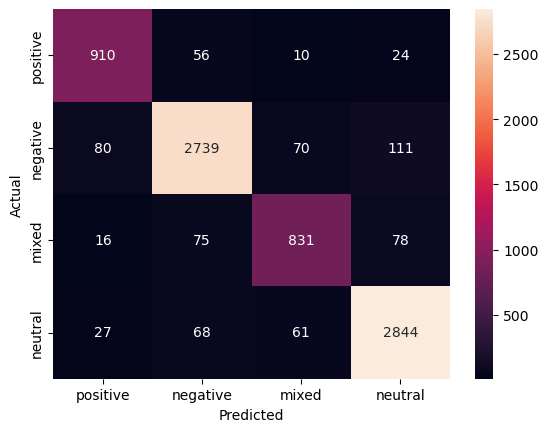

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["positive", "negative", "mixed", "neutral"]

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [13]:
print(classification_report(y, y_pred, target_names=labels))


              precision    recall  f1-score   support

    positive       0.88      0.91      0.90      1000
    negative       0.93      0.91      0.92      3000
       mixed       0.85      0.83      0.84      1000
     neutral       0.93      0.95      0.94      3000

    accuracy                           0.92      8000
   macro avg       0.90      0.90      0.90      8000
weighted avg       0.92      0.92      0.92      8000



In [14]:
X_text_only = X.copy()
X_text_only[:, 384:] = 0

X_no_emoji = X.copy()
X_no_emoji[:, 384:400] = 0

X_no_meta = X.copy()
X_no_meta[:, 400:402] = 0


In [15]:
def avg_confidence(X_input):
    with torch.no_grad():
        probs = torch.softmax(model(torch.tensor(X_input, dtype=torch.float32)), dim=1)
        return probs.max(dim=1).values.mean().item()

full = avg_confidence(X)
text_only = avg_confidence(X_text_only)
no_emoji = avg_confidence(X_no_emoji)
no_meta = avg_confidence(X_no_meta)

print("Full model:", full)
print("Text only:", text_only)
print("No emoji:", no_emoji)
print("No metadata:", no_meta)


Full model: 0.9731875658035278
Text only: 0.9596091508865356
No emoji: 0.9724411368370056
No metadata: 0.9605230689048767
